Mata Kuliah FSD

Kelas A

Anggota Kelompok :

Muhmmad Wahyu Ramadhani - 24523110
Handiva Rahmawan Diachmadja - 24523112

# Dimensionality Reduction dengan PCA dan t-SNE
## Studi Kasus: Segmentasi Pelanggan Mal (Kaggle - Mall Customer Segmentation Data)

**Tugas Praktik 25 — Dimensionality Reduction (PCA & t-SNE)**

Sumber dataset: Kaggle — *Mall Customer Segmentation Data*
(https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

## 1. Deskripsi Kasus

**Masalah yang dihadapi:**
Sebuah pusat perbelanjaan (mal) memiliki data 200 pelanggan yang mencakup
**Gender, Age (usia), Annual Income (pendapatan tahunan), dan Spending Score
(skor belanja 1-100)**. Pihak mal ingin memahami apakah ada **kelompok
(segmen) pelanggan** dengan karakteristik serupa, misalnya "pendapatan
tinggi tapi belanja rendah" atau "pendapatan rendah tapi belanja tinggi",
supaya strategi pemasaran bisa lebih tepat sasaran untuk tiap segmen.

Karena data pelanggan terdiri dari beberapa fitur numerik sekaligus
(usia, pendapatan, skor belanja, dan gender yang di-encode), sulit untuk
melihat pola pengelompokan hanya dengan melihat tabel angka mentah atau
satu scatter plot 2 fitur saja.

**Mengapa dimensionality reduction dibutuhkan:**
Dimensionality reduction memungkinkan seluruh fitur pelanggan diproyeksikan
ke ruang 2D, sehingga pola pengelompokan (cluster) pelanggan bisa
divisualisasikan dan diinterpretasikan secara visual sekaligus, alih-alih
menganalisis kombinasi fitur satu per satu.

**Kasus penggunaan pada notebook ini: Eksplorasi cluster / customer
segmentation** — kita ingin melihat apakah pelanggan mal secara alami
membentuk kelompok-kelompok berbeda berdasarkan usia, pendapatan, dan
perilaku belanjanya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

plt.rcParams["figure.dpi"] = 100

## 2. Dataset

**Sumber:** Kaggle - *Mall Customer Segmentation Data*
(`Mall_Customers.csv`, 200 baris, 5 kolom)


In [2]:
!wget -q https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv
df = pd.read_csv("Mall_Customers.csv")
print("Jumlah sampel :", df.shape[0])
print("Jumlah kolom  :", df.shape[1])
print("\nInfo kolom:")
print(df.dtypes)
df.head()

Jumlah sampel : 200
Jumlah kolom  : 5

Info kolom:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Dataset berisi 200 pelanggan dengan kolom `CustomerID` (identifier, akan
dibuang), `Gender` (kategorikal, di-encode jadi numerik), `Age`,
`Annual Income (k$)`, dan `Spending Score (1-100)`. Tidak ada label kelas
eksplisit di dataset ini — cluster yang muncul murni hasil pengelompokan
tanpa supervisi (unsupervised).

In [4]:
# Encode Gender jadi numerik (0 = Female, 1 = Male) dan buang CustomerID
data = df.drop(columns=["CustomerID"]).copy()
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

feature_cols = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = data[feature_cols].values
print("Fitur yang dipakai:", feature_cols)
print("Shape data fitur  :", X.shape)

Fitur yang dipakai: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape data fitur  : (200, 4)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Sebagai referensi visual tambahan (bukan untuk mereduksi dimensi, tapi
untuk memberi "label warna" pada hasil PCA/t-SNE), kita jalankan K-Means
dengan k=5 pada data yang sudah discaling. Label cluster ini yang nanti
dipakai untuk mewarnai titik-titik pada hasil PCA dan t-SNE.

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
data["Cluster"] = cluster_labels
print("Jumlah anggota tiap cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Jumlah anggota tiap cluster:
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


## 3. Penerapan PCA (Principal Component Analysis)

PCA adalah metode **linear** yang mencari arah (komponen utama) dengan
variansi terbesar dalam data, lalu memproyeksikan data ke arah tersebut.

In [7]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("Explained variance ratio tiap komponen:", np.round(explained, 3))
print(f"Total variansi yang dipertahankan (2D, PC1+PC2): {explained[:2].sum()*100:.1f}%")
print(f"Total variansi yang dipertahankan (3D, PC1+PC2+PC3): {explained[:3].sum()*100:.1f}%")

Explained variance ratio tiap komponen: [0.337 0.262 0.233]
Total variansi yang dipertahankan (2D, PC1+PC2): 59.9%
Total variansi yang dipertahankan (3D, PC1+PC2+PC3): 83.2%


### Visualisasi PCA 2D

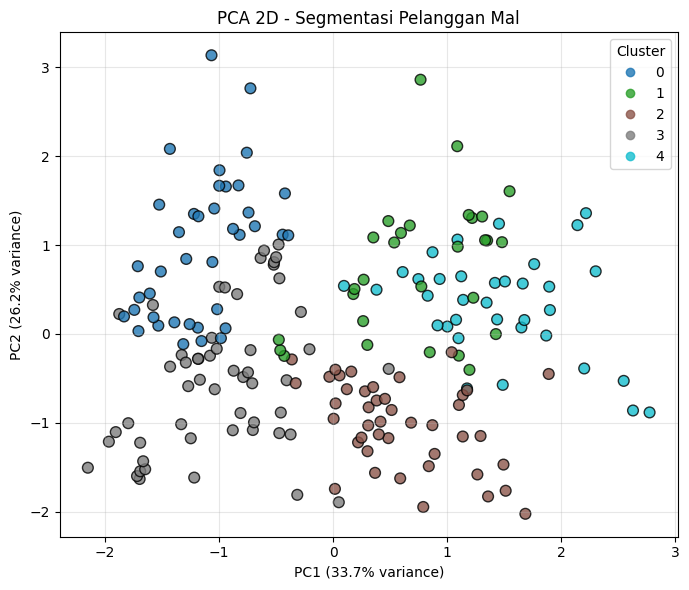

In [8]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.8, edgecolor="k", s=60)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("PCA 2D - Segmentasi Pelanggan Mal")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_2d.png", dpi=150)
plt.show()

### Visualisasi PCA 3D

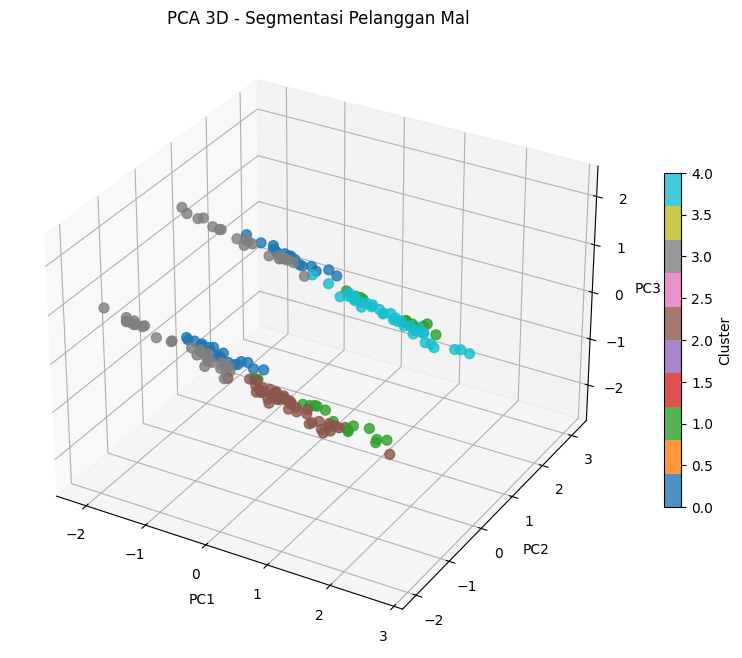

In [9]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=cluster_labels, cmap="tab10", alpha=0.8, s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D - Segmentasi Pelanggan Mal")
fig.colorbar(p, ax=ax, shrink=0.5, label="Cluster")
plt.tight_layout()
plt.savefig("pca_3d.png", dpi=150)
plt.show()

### Makna Hasil PCA

PC1 dan PC2 bersama-sama menjelaskan sebagian variansi utama dari 4 fitur
pelanggan (gender, usia, pendapatan, skor belanja). Pada scatter plot 2D
terlihat beberapa kelompok pelanggan yang cukup terpisah, meski ada
beberapa cluster yang saling berdekatan/tumpang tindih di area tengah.
Ini masuk akal karena PCA memproyeksikan berdasarkan variansi gabungan
dari 4 fitur sekaligus, sehingga cluster yang sebenarnya hanya berbeda
pada 1-2 fitur saja (misalnya hanya beda di "Spending Score") bisa terlihat
tumpang tindih ketika keempat fitur digabung secara linear.

## 4. Penerapan t-SNE

In [10]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_scaled)

### Visualisasi t-SNE 2D

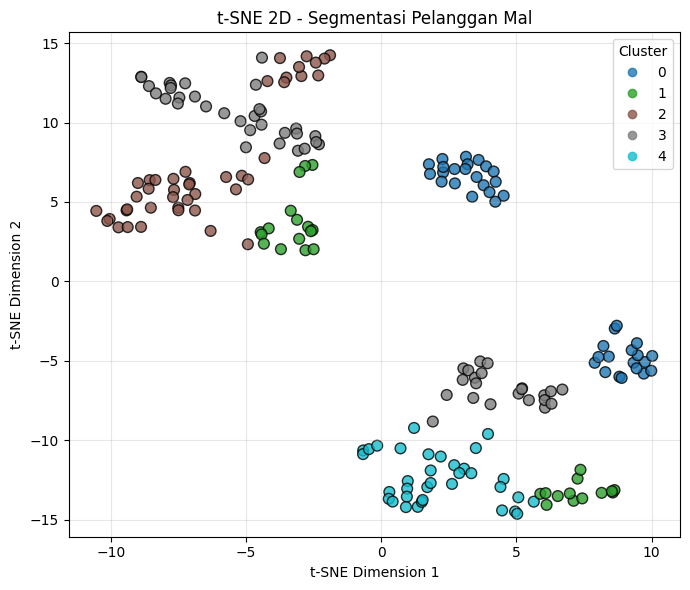

In [11]:
plt.figure(figsize=(7, 6))
scatater = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap="tab10", alpha=0.8, edgecolor="k", s=60)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE 2D - Segmentasi Pelanggan Mal")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_2d.png", dpi=150)
plt.show()

### Pola/Cluster yang Terbentuk pada t-SNE

Hasil t-SNE menunjukkan pemisahan cluster pelanggan yang **jauh lebih
rapat dan tegas** dibandingkan PCA. Kelima segmen pelanggan
(misalnya: "income tinggi & spending tinggi", "income rendah & spending
tinggi", "income & spending sedang", dst.) terlihat sebagai kelompok-
kelompok titik yang terpisah jelas satu sama lain. Ini terjadi karena
t-SNE fokus menjaga kemiripan lokal antar pelanggan (bukan variansi
gabungan seperti PCA), sehingga pelanggan dengan kombinasi usia/
pendapatan/skor belanja yang mirip dikelompokkan sangat berdekatan.

## 5. Analisis: PCA vs t-SNE

| Aspek | PCA | t-SNE |
|---|---|---|
| Sifat metode | Linear | Non-linear |
| Yang dipertahankan | Variansi global | Struktur/kemiripan lokal |
| Interpretasi sumbu | Bermakna (explained variance, kombinasi linear fitur asli) | Tidak bermakna langsung, hanya untuk visualisasi |
| Kecepatan komputasi | Sangat cepat | Lebih lambat (kompleksitas kuadratik) |
| Konsistensi hasil | Deterministik | Stokastik, sensitif terhadap parameter perplexity |
| Hasil cluster pada kasus ini | Beberapa cluster tumpang tindih di area tengah | Cluster terpisah jauh lebih tegas |

**Perbedaan hasil:** PCA menghasilkan pemisahan yang cukup terlihat namun
beberapa cluster pelanggan saling berdekatan/tumpang tindih karena PCA
hanya mempertahankan arah variansi gabungan terbesar tanpa memedulikan
hubungan lokal antar pelanggan. t-SNE menghasilkan pemisahan segmen
pelanggan yang jauh lebih jelas dan mudah dibaca secara visual, karena
berfokus menjaga kedekatan lokal antar pelanggan yang benar-benar mirip
perilakunya.

**Metode mana yang lebih sesuai untuk kasus ini?**
Untuk kasus **customer segmentation / eksplorasi cluster** seperti pada
notebook ini, **t-SNE lebih unggul secara visual** karena menghasilkan
segmen pelanggan yang jauh lebih mudah diidentifikasi dan dijelaskan ke
tim marketing (misalnya untuk membuat strategi promosi per segmen).
Namun, **PCA tetap lebih unggul** bila:
- Dibutuhkan reduksi fitur yang cepat & deterministik sebagai tahap
  preprocessing sebelum model prediktif lain (misalnya model prediksi
  churn pelanggan)
- Ingin mengetahui fitur mana (usia/pendapatan/skor belanja) yang paling
  berkontribusi terhadap variansi data secara kuantitatif

**Kesimpulan:** untuk tujuan **memahami & mempresentasikan segmen
pelanggan secara visual**, gunakan **t-SNE**. Untuk tujuan **preprocessing
sebelum modeling lanjutan**, gunakan **PCA** karena lebih cepat, stabil,
dan mudah diinterpretasikan lewat explained variance.